In [119]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pickle
from pathlib import Path
from typing import Tuple
from datetime import datetime
from lifelines.utils import concordance_index

# import lifelines coxphitter

from lifelines import CoxPHFitter

#add path path to data folder using sys.path
sys.path.append('../data_process/')
from data_process import load_dataset
from processors.outcomes import get_first_diagnosis
from helpers import * 

import warnings
warnings.filterwarnings('ignore')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
DATA_PATH = '/Users/aashnashah/Desktop/ssh_mount/SETPOINT/data/processed/'

mortality_df = pd.read_csv(os.path.join(DATA_PATH, 'mortality.csv'))
diagnosis_df = pd.read_csv(os.path.join(DATA_PATH, 'diagnosis.csv'))
first_diagnosis_df = get_first_diagnosis(diagnosis_df)
measurements_df = pd.read_csv(os.path.join(DATA_PATH, 'body_measurements.csv'))
demo_df = pd.read_csv(os.path.join(DATA_PATH, 'demographics.csv')).drop(columns=['observation_period_start_time'])
cbc_df = pd.read_csv(os.path.join(DATA_PATH, 'cbc_measurements.csv'))

patient_df = demo_df.merge(mortality_df, on='subject_id', how='left')
patient_df['time_of_death'] = pd.to_datetime(patient_df['time_of_death'])
patient_df['days_between_visit_and_death'] = (patient_df['time_of_death'] - pd.to_datetime(patient_df['observation_period_end_time'])).dt.days
display(patient_df.query('days_between_visit_and_death < 0').head(3))

,subject_id,gender,dob,race,ethnicity,observation_period_end_time,time_of_death,days_between_visit_and_death
3,115967098,F,1943-12-15 00:00:00,5,Not Hispanic,2000-03-13,2000-01-13 23:59:59,-60.0
16,115967114,F,1972-09-01 00:00:00,2,Not Hispanic,2014-06-11,2014-04-12 23:59:59,-60.0
25,115967128,F,1948-04-22 00:00:00,5,Not Hispanic,2020-11-10,2020-09-11 23:59:59,-60.0


In [3]:
def plot_concordance(results, title):
    # get code and columns that end with _concordance
    concordance_cols = [col for col in results.columns if col.endswith('concordance')]
    results = results[['Code'] + concordance_cols + ['Biomarker']]
    results = results.melt(id_vars=['Code', 'Biomarker'], var_name='Set', value_name='concordance')
    results['Set'] = results['Set'].str.split('_').str[0].str.capitalize()
    # plot the code on the x axis and the concordance on the y axis
    fig, ax = plt.subplots(1, 2, figsize=(5, 2), sharey=True)
    df_setpoint = results[results['Biomarker'] == 'setpoint_normalized']
    df_cv = results[results['Biomarker'] == 'cv_normalized']
    sns.barplot(data=df_setpoint, x='Code', y='concordance', hue='Set', ax=ax[0])
    sns.barplot(data=df_cv, x='Code', y='concordance', hue='Set', ax=ax[1])
    ax[0].set_title('Setpoint')
    ax[1].set_title('CV')
    plt.suptitle(title)
    return fig, ax

(<Figure size 750x300 with 2 Axes>,
 array([<Axes: title={'center': 'Setpoint'}, xlabel='Code', ylabel='concordance'>,
        <Axes: title={'center': 'CV'}, xlabel='Code', ylabel='concordance'>],
       dtype=object))

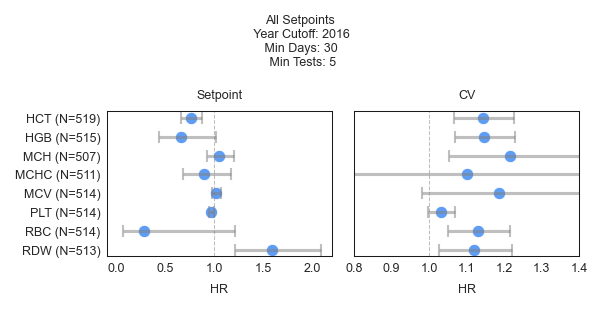

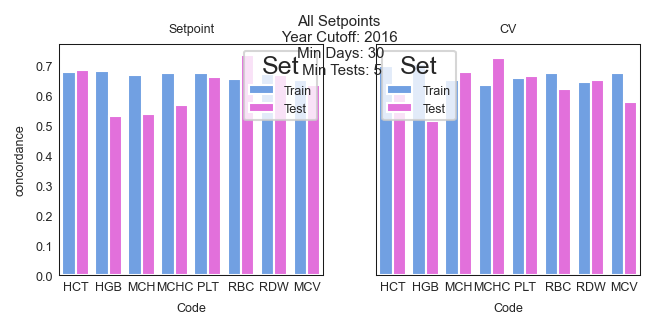

In [4]:
min_days = 30
min_test = 5
year_cutoff = 2016
measurements_df = pd.read_csv(os.path.join(DATA_PATH, 'body_measurements.csv'))
min_time_since_setpoint = 0 
max_time_since_setpoint = 365*3

setpoints = pd.read_csv(f'../results/setpoint_calculations/setpoints_gap:{min_days}_tests:{min_test}_year:{year_cutoff}.csv')
df = (setpoints
    .merge(demo_df, on='subject_id', how='left')
    .merge(mortality_df, on='subject_id', how='left'))
df = convert_to_datetime(df) 
df = merge_setpoints_and_measurements(df, measurements_df, 'setpoint_estimation_time')
      
setpoints_2016 = run_cox_analysis(df, 30, 5, 2016, [], use_train_test=True)
setpoints_2016_with_BMI= run_cox_analysis(df, 30, 5, 2016, ['BMI'], use_train_test=True)
setpoints_2016_BMI_cat = run_cox_analysis(df, 30, 5, 2016, ['BMI_category_Morbid Obesity', 'BMI_category_Obesity', 'BMI_category_Overweight', 'BMI_category_Underweight'], use_train_test=True)

plot_setpoint_hr(setpoints_2016_BMI_cat[0], f'All Setpoints \n Year Cutoff: {year_cutoff} \n Min Days: {min_days} \n Min Tests: {min_test}')
plot_concordance(setpoints_2016_BMI_cat[0], f'All Setpoints \n Year Cutoff: {year_cutoff} \n Min Days: {min_days} \n Min Tests: {min_test}')

In [131]:
import warnings
warnings.filterwarnings('ignore')

min_days = 30
min_test = 5
year_cutoff = 2016
min_time = 0
max_time = 365*3

setpoints = pd.read_csv(f'../results/setpoint_calculations/setpoints_gap:{min_days}_tests:{min_test}_year:{year_cutoff}.csv')
df = (setpoints
            .merge(demo_df, on='subject_id', how='left')
            .merge(mortality_df, on='subject_id', how='left')
            .merge(cbc_df, on=['subject_id', 'code'], how='left')).dropna(subset=['setpoint_estimation_time'])
df = convert_to_datetime(df)
df = merge_setpoints_and_measurements(df, measurements_df, 'time')

setpoints_prognosis_2016 = run_interval_cox_analysis(df, min_time, max_time, [], use_train_test=True, setpoint_in_interval=False)
setpoints_prognosis_2016_with_BMI = run_interval_cox_analysis(df, min_time, max_time, ['BMI'], use_train_test=True, setpoint_in_interval=False)
setpoints_prognosis_2016_with_BMI_Category = run_interval_cox_analysis(df, min_time, max_time, ['BMI_category_Morbid Obesity', 'BMI_category_Obesity', 'BMI_category_Overweight', 'BMI_category_Underweight'], use_train_test=True, setpoint_in_interval=False)


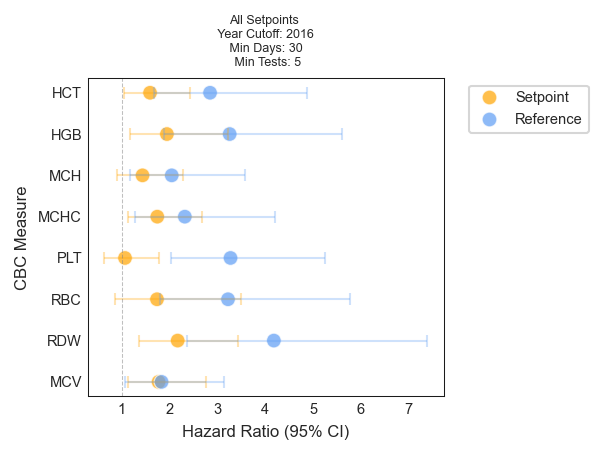

ValueError: 'xerr' must not contain negative values

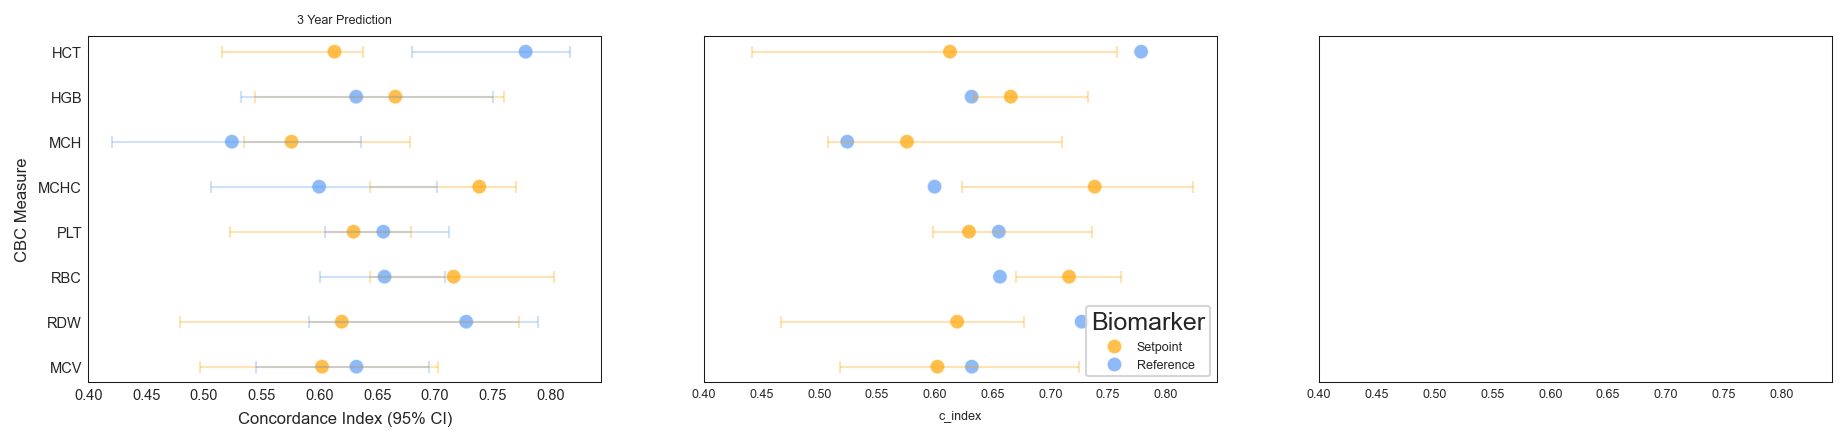

In [132]:

plot_interval_hr(setpoints_prognosis_2016[0], f'All Setpoints \n Year Cutoff: {year_cutoff} \n Min Days: {min_days} \n Min Tests: {min_test}')
# Usage:
fig, axes = plot_interval_concordance(setpoints_prognosis_2016[1], 
                                   f'All Setpoints \n Year Cutoff: {year_cutoff} \n Min Days: {min_days} \n Min Tests: {min_test}')
plt.show()


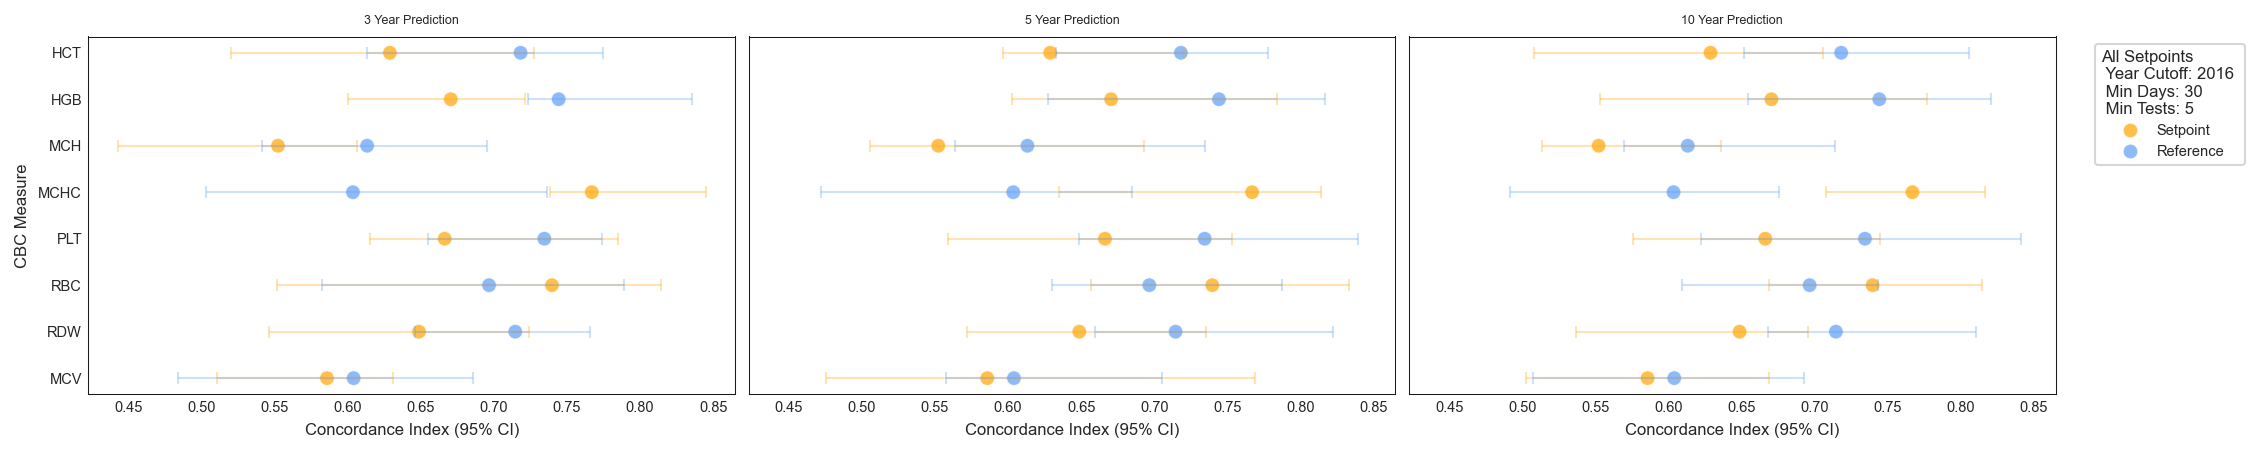

In [130]:
fig, axes = plot_interval_concordance(setpoints_prognosis_2016_with_BMI[1], 
                                   f'All Setpoints \n Year Cutoff: {year_cutoff} \n Min Days: {min_days} \n Min Tests: {min_test}')
plt.show()
